In [ ]:
# Introduction to classification and logistic regression

In [ ]:
# Classification: it is a type of machine learning algorithm used for prediction of categorical output variables

# types of classification:
    # 1. Binary classification: It is a type of classification where the output variable has only two possible values.
    # 2. Multi-class classification: It is a type of classification where the output variable has more than two possible values for the different classes.
    # 3. Multi-label classification: It is a type of classification where the output variable has more than two possible values for the same class.

# Common Use Cases:
    # 1. Image Classification: It is used to identify and classify objects in images.
    # 2. Text Classification: It is used to identify and classify text data.
    # 3. Fraud Detection: It is used to detect fraudulent transactions.
    # 4. Medical Diagnosis: It is used to diagnose diseases and conditions.

In [ ]:
# Logistic Regression: It is a linear model for classification problems and is based on the logistic function (sigmoid function).
# Sigmoid function: It is a function that maps any real-valued number into the range (0,1).

# formula of Logistic Regression: P(y=1|x) = 1/(1+e^(-z))
# where z = beta_0 + beta_1 * x_1 + beta_2 * x_2 + ... + beta_n * x_n

# Logistic Regression for Binary Classification:

# Logistic Regression is a binary classification model that predicts the probability of a binary outcome (0 or 1) based on one or more input features.

# Logistic Regression Model:
    # -Equation:
        # -Logistic regression applies the sigmoid function to the linear combination of the input features to produce a probability value between 0 and 1.
        # -p(y=1|x) = sigma(z)
        # -where sigma(z) = 1/(1+e^(-z)) it is the sigmoid function
        # -z = beta_0 + beta_1 * x_1 + beta_2 * x_2 + ... + beta_n * x_n
        # -p(y=1|x):probability of the positive class given the input features x
        # -beta_0: intercept term
        # -beta_1, beta_2, ... beta_n: coefficients for the input features

    # Sigmoid Function:
        # -Maps the output to a range between 0 and 1
        # Sigma(z)=1/(1+e^-z)
        # if p(y=1|x) >=0.5, the prediction is class 1; otherwise, it is class 0
    # 
    # Decision Boundary:
        #-The threeshold(default is 0.5) used to classify instances
        # -Decision boundaries can be adjusted to optimize for precison

    # Interpretation of coefficients:
        #-beta_zero : intercept, the baseline probability
        # -beta_i : effect of feature x_i on the log-odds of the positive class  
        

In [2]:
# Sigmoid Function in Action:
    # -The Sigmoid function outputs are interpretable as probabilities
    # -Visulization of the sigmoid function can illustrate how probabilities are mapped from raw model predictions

# Decision Boundary
    # - Default threshold is 0.5
    # - Adjusting the threshold can balance precision and recall depending on the use case


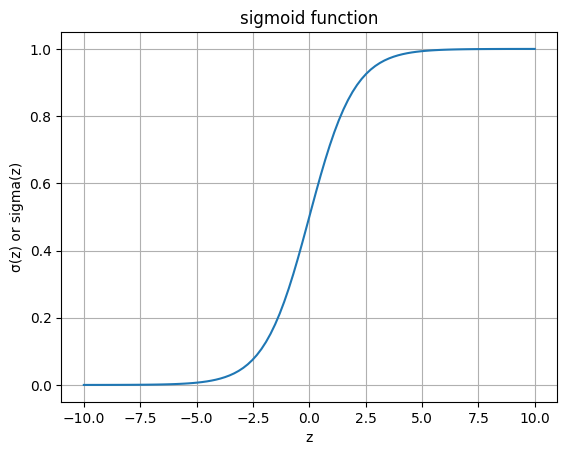

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# sigmoid Function
def sigmoid(z):
    return 1 /  (1 + np.exp(-z))

# Generate values
z=np.linspace (-10, 10, 100)
sigmoid_values=sigmoid(z)

# plt
plt.plot(z, sigmoid_values)
plt.title('sigmoid function')
plt.xlabel('z')
plt.ylabel('σ(z) or sigma(z)')
plt.grid()
plt.show()

In [8]:
# excerise

accuracy 1.0
precison 1.0
recall_score 1.0
f1_score 1.0

 classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


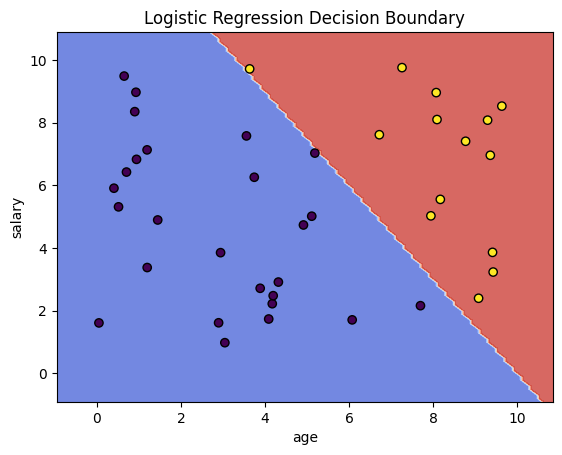

In [ ]:
# implement a logistic regression model to classify a dataset(eg: predicitng if a customer will make a purchase)
# Anlayze the model performance using metrics such as accuracy, precision, recall, and F1 score  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# generate the data
np.random.seed(42)
n_samples=200
X=np.random.rand(n_samples, 2)*10
y=(X[: , 0] * 1.5 + X[:, 1] > 15).astype(int)

# create a dataframe
df=pd.DataFrame(X, columns=['age','salary'])
df['purchase']=y

# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(df[['age','salary']], df['purchase'], test_size=0.2, random_state=42)

# trsin the logistic regression model
model=LogisticRegression()
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Evaluate Performance
print("accuracy", accuracy_score(y_test, y_pred))
print("precison", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("\n classification report:\n", classification_report(y_test, y_pred))

# Visualize the data
# plot decision boundary

x_min, x_max = X[:, 0].min() -1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() -1, X[:, 1].max() +1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# predict probabilities for grid points
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# plot
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test['age'], X_test['salary'], c=y_test, cmap='viridis', edgecolors="k")
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("age")
plt.ylabel("salary")
plt.show()



In [ ]:
from sklearn.datasets import fetch_covtype

# load the data
covtype=fetch_covtype
print(covtype)